<a href="https://colab.research.google.com/github/RicardoMarinho-code/machine-learning-class/blob/main/deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import torch

#funções para redes
import torch.nn.functional as F

#pytorch para visão computacional
import torchvision

import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

In [11]:
transform = transforms.ToTensor() #define a conversão de imagem para tensor (uma extensão da bibliote)

trainset = datasets.MNIST('./MNIST_data/', download=True, train=True, transform=transform) #carrega parte do treino do dataset
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True) # Cria um buffer para pegar os dados por partes

valset = datasets.MNIST('./MNIST_data/', download=True, train=False, transform=transform) #carrega a parte de validação do dataset
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True) #cria um buffer para pegar os dados por partes


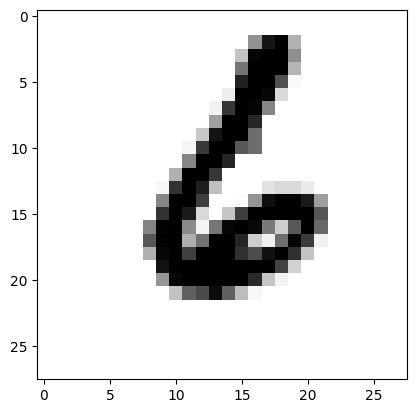

In [12]:
dataister = iter(trainloader)
imagens, etiquetas = next(dataister)
plt.imshow(imagens[0].numpy().squeeze(), cmap='gray_r');

In [13]:
print(imagens[0].shape) #verificar as dimensões do tensor de cada imagem
print(etiquetas[0].shape)#verificar as dimensões do tensor de cada etiqueta

torch.Size([1, 28, 28])
torch.Size([])


In [14]:
class Modelo (nn.Module):
  def __init__(self):
    super(Modelo, self).__init__()
    self.linear1 = nn.Linear(28*28, 128) #camada de entrada, 784 neurônios que se ligam a 128
    self.linear2 = nn.Linear(128, 64) #camada interna 1, 128 neuronios que se ligam a 64
    self.linear3 = nn.Linear(64, 10) # camada interna 2, 64 neurônios que se ligam a 10
    #para a camada de saída, não é necessário definir nada, pois só precisamos pegar o output da camada interna 2

  def forward(self, X):
    X = F.relu(self.linear1(X)) #função de ativação da camada de entrada para a camada interna 1
    X = F.relu(self.linear2(X)) # função de ativação da camada interna 1 para a camada interna 2
    X = self.linear3(X) # função de ativação da camada interna 2 para a camada de saída. Nesse caso f(x) = x
    return F.log_softmax(X, dim=1) #dados utilizados para calcular a perda

In [15]:
def treino(modelo, trainloader, device):

  """estrutura de treinamento próprio da inception v3"""

  otimizador = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.5) #define a política de atualização dos pesos e das bias
  inicio = time() #timer para saber quanto tempo levou

  criterio = nn.NLLLoss() #definindo o critério para calcular a peerda
  EPOCHS = 10 #numero de epochs que o algoritmo rodará
  #uma boa época de treinamento é, no mínimo, 10

  modelo.train() #iniciando o modo de treinamento do modelo

  for epoch in range(EPOCHS):
    perda_acumulada = 0.0 #inicialização da perda acumulada da epoch em questao

    for imagens, etiquetas in trainloader:
      imagens = imagens.view(imagens.shape[0], -1) #convertendo imagens em "vetores" de 28*28 casas para ficarem compatíveis
      otimizador.zero_grad() #zerando os gradientes por conta do ciclo anterior

      output = modelo(imagens.to(device)) #colocando os dados no modelo
      perda_instantanea = criterio(output, etiquetas.to(device)) #calculando a perda da epoch em questao

      perda_instantanea.backward() #back proragation a partir da perda
      otimizador.step() #atualizando os pesos e a bias

      perda_acumulada += perda_instantanea.item() #atualização da perda acumulada

In [16]:
def validacao(modelo, valloader, device):
  conta_corretas, conta_todas = 0, 0
  for imagens, etiquetas in valloader:
    for i in range(len(etiquetas)):
      img = imagens[i].view(1, 784)
      #desativar o autgrad para acelerar a validação. Grafos computacionais dinâmicos tem custo alto de processamento
      with torch.no_grad():
        logps = modelo(img.to(device))
        #output do modelo em escala logarítmica
  ps = torch.exp(logps) #converte output para escala normal (lembrando que é um tensor)
  probab = (list(ps.cpu().numpy()[0]))
  etiqueta_pred = probab.index(max(probab)) #converte o tensor em um numero. No caso, o numero que o modelo previu
  etiqueta_certa = etiquetas.numpy()[i]
  if(etiqueta_certa == etiqueta_pred): #compara a previsão com o valor correto
    conta_corretas += 1
  conta_todas += 1

  print("Total de imagens testadas =", conta_todas)
  print("\nPrecisão do modelo = {}%".format(conta_corretas*100/conta_todas))


In [17]:
modelo = Modelo() #instanciando o modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #definindo o dispositivo que será utilizado
modelo.to(device)

Modelo(
  (linear1): Linear(in_features=784, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=10, bias=True)
)